# Model SARIMA - Anàlisi de sèries temporals (Sèrie 1)

Aquest notebook analitza la sèrie temporal de casos de grip en població de 15 anys o més a Barcelona ciutat, a partir de dades setmanals del període 2012–2024, utilitzant la metodologia Box-Jenkins. 

## Metodologia

1. Anàlisi exploratòria
2. Anàlisi d’estacionarietat
3. Identificació del model
4. Estimació del model
5. Validació
6. Predicció

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
import skforecast
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme, plot_prediction_intervals
from skforecast.stats import Sarimax, Arima
from skforecast.recursive import ForecasterStats
from skforecast.utils import expand_index
from skforecast.model_selection import TimeSeriesFold, backtesting_stats, grid_search_stats

warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

## Filtratge de dades

Es selecciona el subconjunt corresponent a:

- Diagnòstic: Grip
- Regió: Barcelona Ciutat
- Grup d'edat: 15+

In [2]:
df_serie = df[
    (df["nom_regio"] == "Barcelona Ciutat") &
    (df["diagnostic"] == "Grip") &
    (df["edat_bin"] == "15+")
    ]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

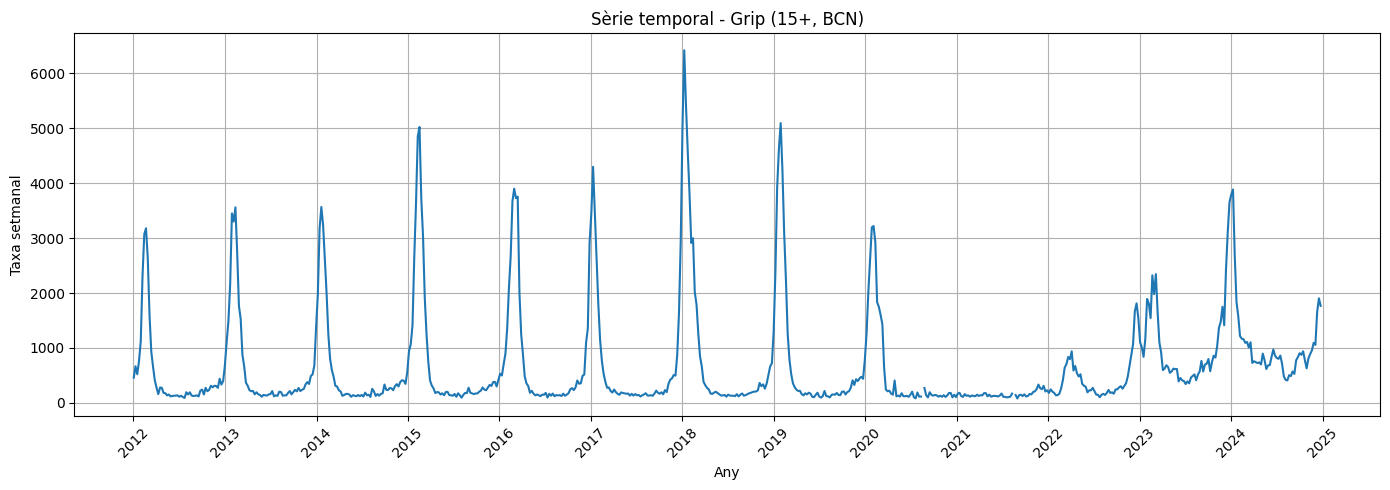

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Sèrie temporal - Grip (15+, BCN)")
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Divisió Train-Test

El conjunt de dades es divideix en:

- Conjunt d’entrenament: utilitzat per a l’estimació del model (2012–2019)  
- Conjunt test: utilitzat per a la validació i l’avaluació del rendiment predictiu (2020–2024)

In [4]:
serie_1 = serie.copy()

train = serie_1[serie_1.index < "2020-01-01"]
test  = serie_1[serie_1.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


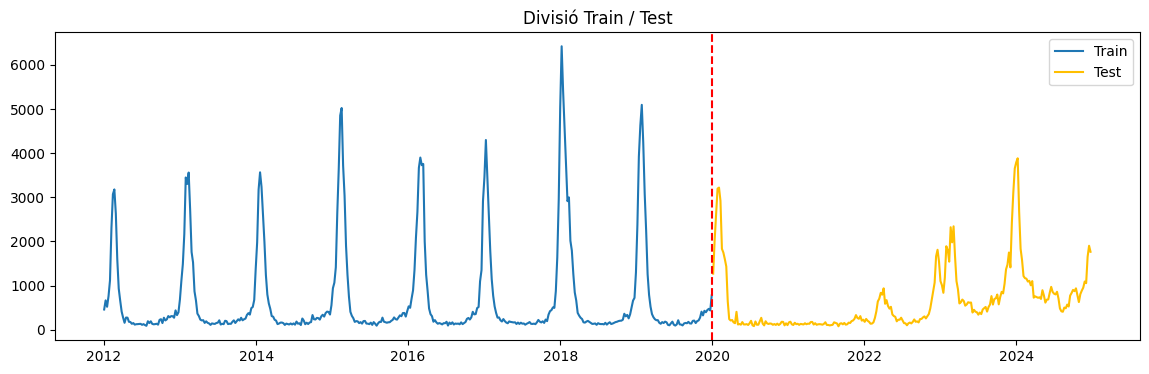

In [5]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train / Test")
plt.show()

## Anàlisi exploratòria

La sèrie temporal original mostra:

- un patró estacional anual molt marcat
- pics epidèmics pronunciats que es repeteixen cada any
- i canvis en la variabilitat segons el nivell de la sèrie

En particular, els anys amb incidències més elevades tendeixen a presentar fluctuacions més grans, fet que suggereix que la variància podria no ser estable en l’escala original. Per aquest motiu, es considera una transformació estabilitzadora de la variància abans de la modelització.

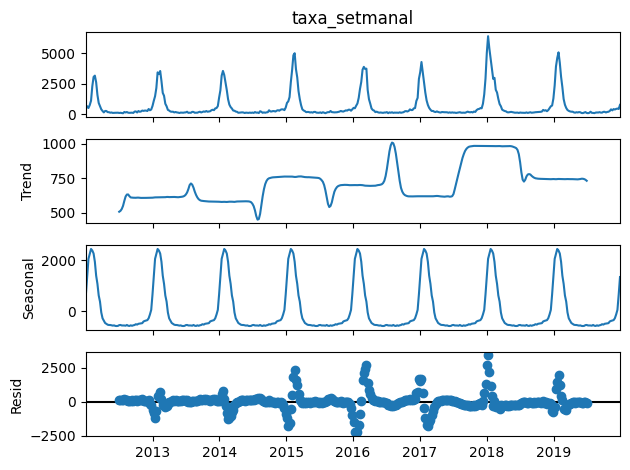

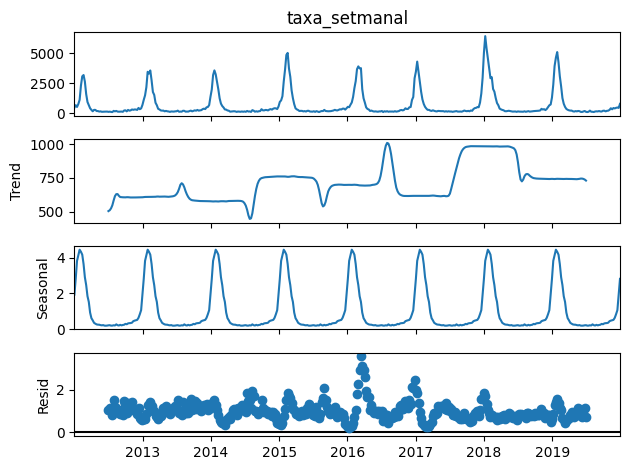

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

decompm = seasonal_decompose(train, model="multiplicative", period=52)
decompm.plot()
plt.show()

Mitjana global (train): 686.9091016273319
Variància global (train): 1183896.2579264757

Mitjana per any:
date
2012-12-31    507.288211
2013-12-31    637.395861
2014-12-31    556.079307
2015-12-31    749.084448
2016-12-31    788.935149
2017-12-31    619.561558
2018-12-31    910.160603
2019-12-31    725.928625
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    5.244344e+05
2013-12-31    8.059521e+05
2014-12-31    7.291890e+05
2015-12-31    1.466850e+06
2016-12-31    1.165860e+06
2017-12-31    9.620598e+05
2018-12-31    2.296626e+06
2019-12-31    1.547799e+06
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


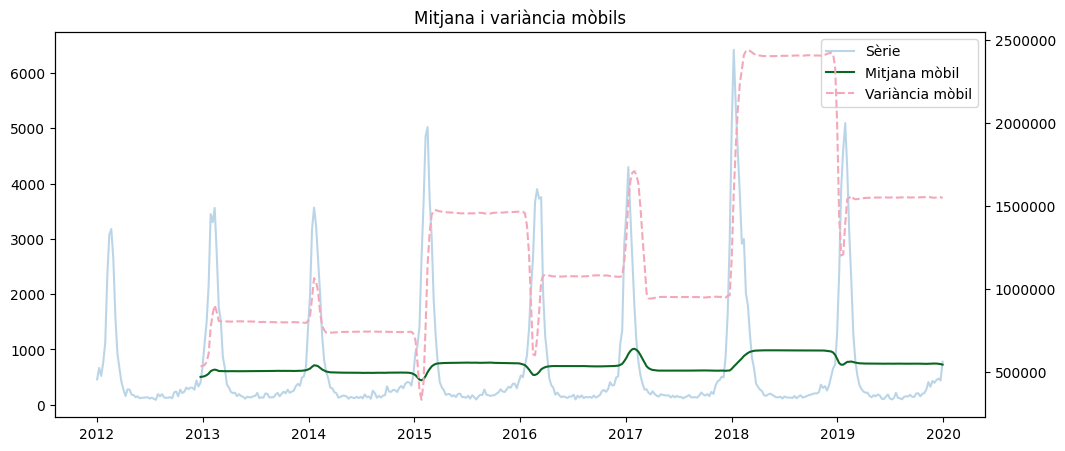

In [7]:
print("Mitjana global (train):", train.mean())
print("Variància global (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\nMitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_mean, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Mitjana i variància mòbils")
plt.show()

## Transformació logarítmica

Com que la variància en l’escala original sembla augmentar amb el nivell de la sèrie, es va considerar una transformació logarítmica.

Després de la transformació, la variabilitat esdevé més homogènia al llarg del temps, i la variància anual és substancialment més estable que en l’escala original. Per aquest motiu, la sèrie transformada logarítmicament es va prendre com a base principal de l’anàlisi.

També es va explorar la versió original, sense logaritme, ja que al principi l’elecció no era completament clara. Tanmateix, els models SARIMA ajustats en l’escala original van produir sistemàticament diagnòstics residuals pitjors, amb autocorrelació restant, heteroscedasticitat i intervals de predicció excessivament amplis. Per tant, l’estratègia final de modelització es va dur a terme sobre la sèrie transformada logarítmicament.

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


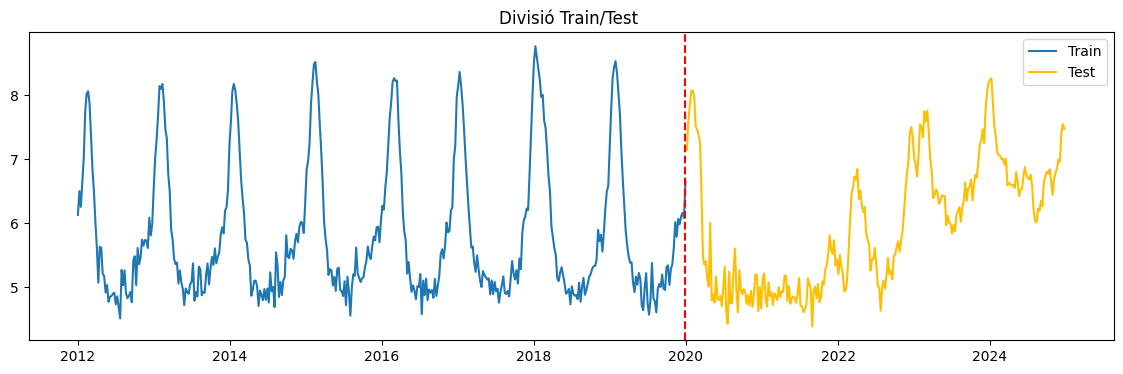

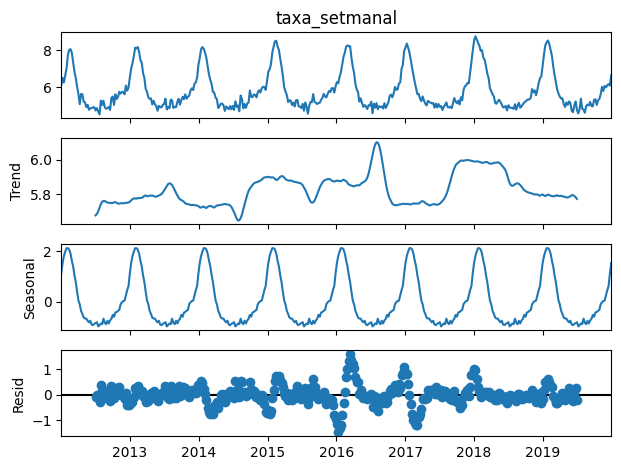

Mitjana global (train_log): 5.809758827482673
Variància global (train_log): 1.107689038078148

 Mitjana per any:
date
2012-12-31    5.688893
2013-12-31    5.828385
2014-12-31    5.701847
2015-12-31    5.857590
2016-12-31    5.970716
2017-12-31    5.740529
2018-12-31    5.923326
2019-12-31    5.766923
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    0.850172
2013-12-31    1.030377
2014-12-31    0.924484
2015-12-31    1.171465
2016-12-31    1.258357
2017-12-31    1.032225
2018-12-31    1.436086
2019-12-31    1.232674
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


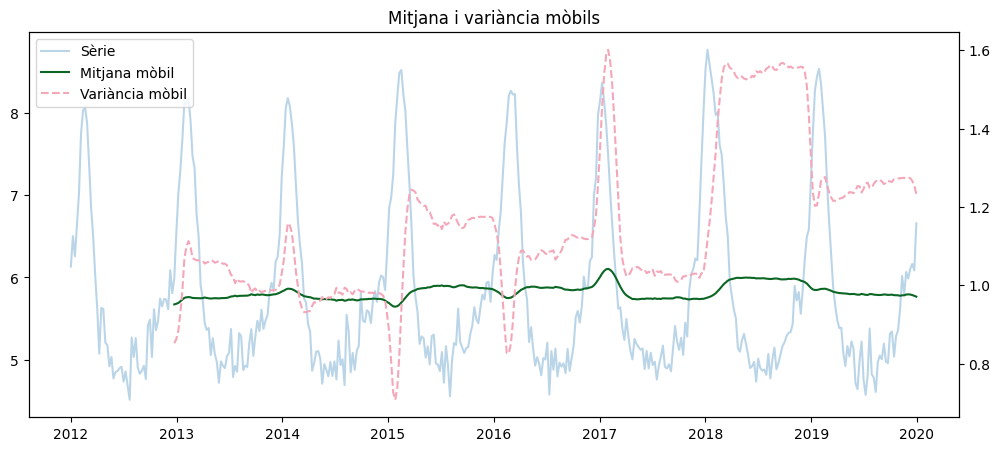

In [8]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print(train_log.index.min(), train_log.index.max())
print(test_log.index.min(), test_log.index.max())

plt.figure(figsize=(14,4))

plt.plot(train_log, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test_log, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train_log.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train/Test ")
plt.show()

decomp_log = seasonal_decompose(train_log, model="additive", period=52)
decomp_log.plot()
plt.show()

print("Mitjana global (train_log):", train_log.mean())
print("Variància global (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\n Mitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_meanlog, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Mitjana i variància mòbils")
plt.show()

## ACF original

Després de la descomposició, s’examina l’ACF de la sèrie original per avaluar la possible presència d’estacionalitat.

Els pics significatius en retards estacionals, especialment al voltant de m = 52, suggereixen un patró estacional anual clar. Això proporciona una primera indicació que podria ser necessària una diferenciació estacional.

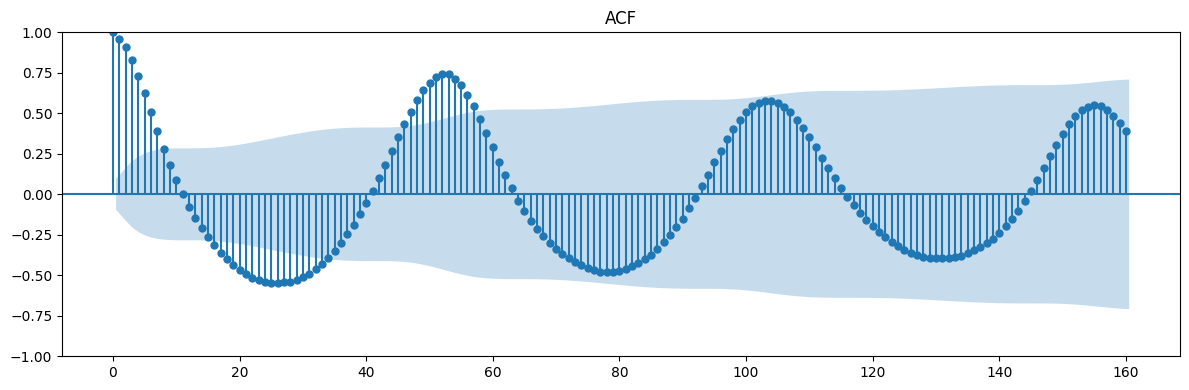

In [9]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF")
plt.tight_layout()
plt.show()

## Anàlisi d’estacionarietat

S’apliquen les proves estadístiques següents:
- Test Augmented Dickey-Fuller (ADF)
- Test KPSS

## Interpretació
- ADF: H0 = no estacionària
- KPSS: H0 = estacionària

Resultats sobre la sèrie transformada logarítmicament:

- Test ADF: es rebutja la hipòtesi nul·la de no estacionarietat.
- Test KPSS: no es rebutja la hipòtesi nul·la d’estacionarietat.

Considerats conjuntament, ambdós tests suggereixen que la sèrie transformada logarítmicament ja és estacionària en sentit no estacional. Per tant, no hi ha evidència sòlida que justifiqui la necessitat d’una diferenciació regular en aquesta etapa.

In [10]:
dftest = adfuller(train_log, autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("P-Valor : ", dftest[1])

stat, p_value, lags, crit = kpss(train_log, regression='c', nlags='auto')

print("\n2. KPSS :", stat)
print("P-valor:", p_value)

1. ADF :  -6.3601307333233335
P-Valor :  2.486249429206904e-08

2. KPSS : 0.02124056640676763
P-valor: 0.1


/var/folders/gl/4q3h26mn17x5r3shw8dj8t280000gn/T/ipykernel_65288/1891530478.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit = kpss(train_log, regression='c', nlags='auto')


## Anàlisi descriptiva

Per complementar els tests estadístics, s’han examinat la mitjana mòbil i la variància mòbil de la sèrie transformada logarítmicament.

La mitjana mòbil es manté relativament estable al llarg del temps, tot i que encara es poden observar alguns canvis moderats de nivell entre anys. Més important encara, la variància anual esdevé molt més estable després de la transformació logarítmica, fluctuant dins d’un rang més estret que en l’escala original.

De manera similar, la variància mòbil ja no mostra la forta inestabilitat observada en la sèrie original, fet que indica que la transformació logarítmica redueix satisfactòriament l’heteroscedasticitat. Tot i que la variància no és perfectament constant, la dependència entre el nivell de la sèrie i la seva variabilitat queda substancialment mitigada.

En conjunt, aquests resultats donen suport a l’ús de la transformació logarítmica i suggereixen que la principal font restant de no estacionarietat és la forta estructura estacional, més que no pas una tendència no estacional.

## Comprovació de la diferenciació estacional

Per avaluar més a fons si la diferenciació estacional és adequada, es compara la sèrie després d’aplicar una diferenciació estacional amb la sèrie original, i s’examina novament l’ACF.

Després d’aplicar la diferenciació estacional, el patró anual repetitiu queda substancialment atenuat, i els pics estacionals de l’ACF esdevenen notablement més febles. Això suporta l’elecció d’una diferenciació estacional d’ordre 1 (D = 1).

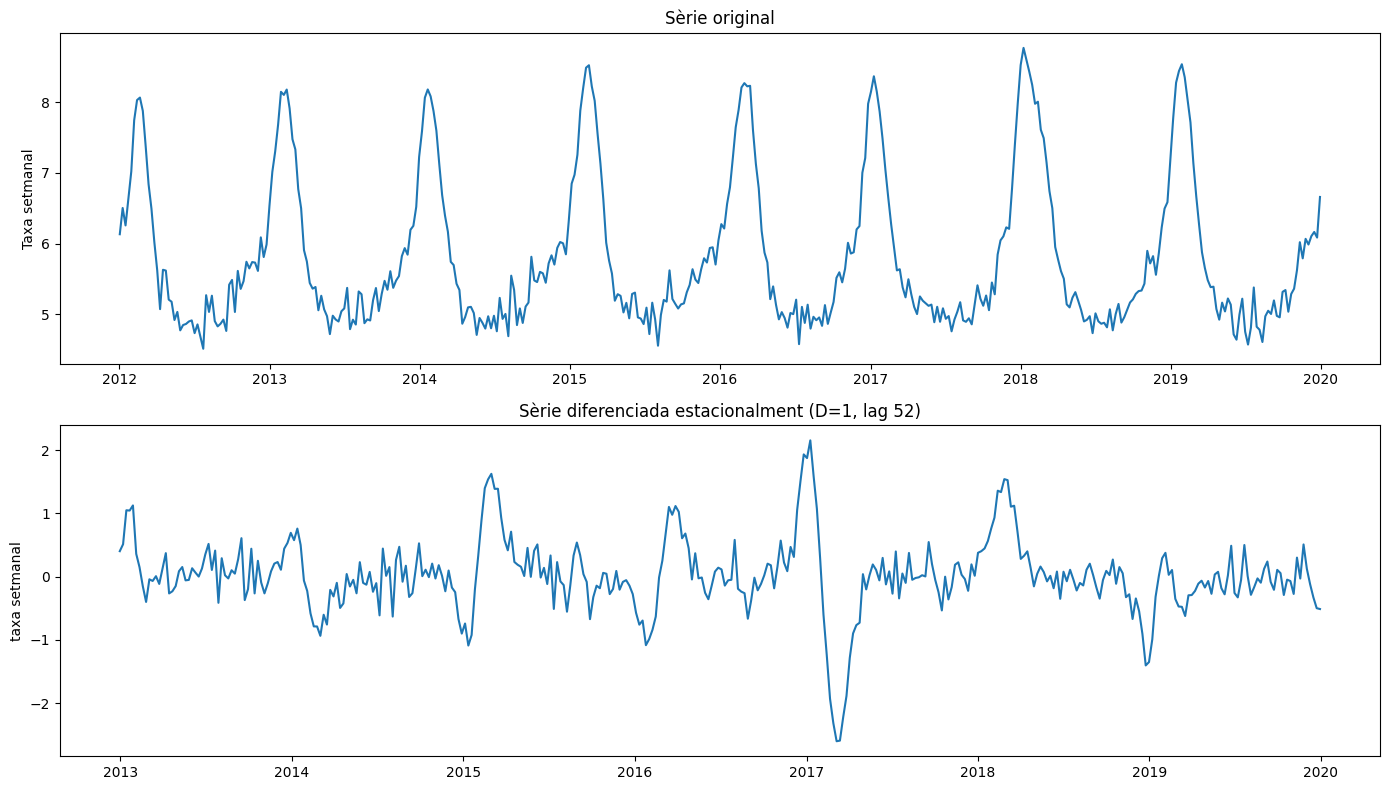

In [11]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Sèrie original")
axes[0].set_ylabel("Taxa setmanal")

axes[1].plot(serie_D1)
axes[1].set_title("Sèrie diferenciada estacionalment (D=1, lag 52)")
axes[1].set_ylabel("taxa setmanal")

plt.tight_layout()
plt.show()

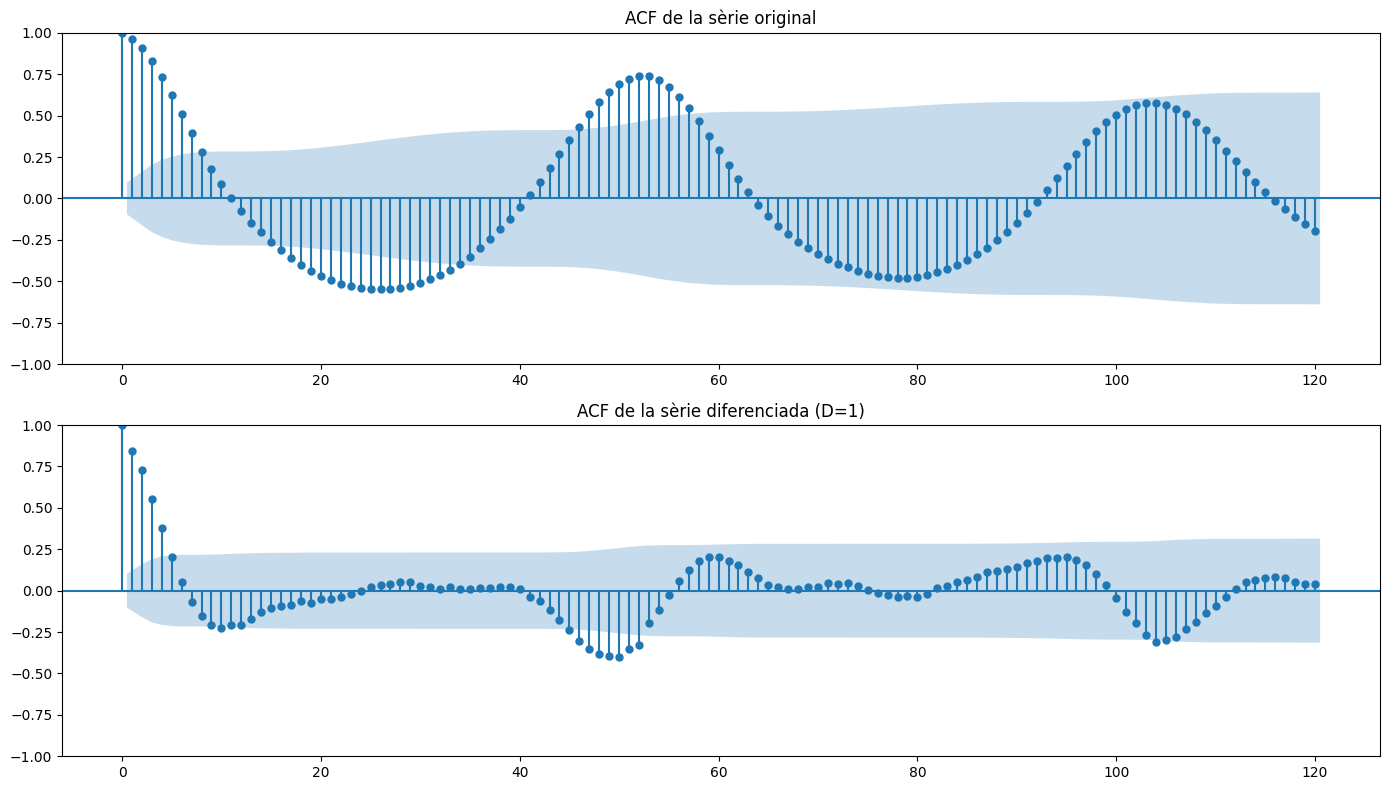

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF de la sèrie original")

plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF de la sèrie diferenciada (D=1)")

plt.tight_layout()
plt.show()

## Selecció de diferenciació

Donat el fort patró epidèmic anual, la diferenciació estacional es va considerar necessària des del principi. L’ACF original mostrava una estructura estacional molt marcada, amb dependència persistent en retards anuals, fet que dona suport a l’ús de la diferenciació estacional.

Després d’aplicar només la diferenciació estacional (D = 1), l’estructura anual es redueix substancialment, i la sèrie resultant fluctua al voltant d’una mitjana més estable. L’ACF encara mostra certa dependència a curt termini, però aquesta pot ser capturada pels termes ARMA del model i no justifica per si sola una diferenciació regular addicional.

A més, quan també es va aplicar una primera diferenciació regular d = 1, D = 1, l’ACF va quedar excessivament aplanada i va mostrar un pic negatiu pronunciat en el retard 1, suggerint sobrediferenciació.

Per tant, l’especificació final adopta només diferenciació estacional: d = 0, D = 1.

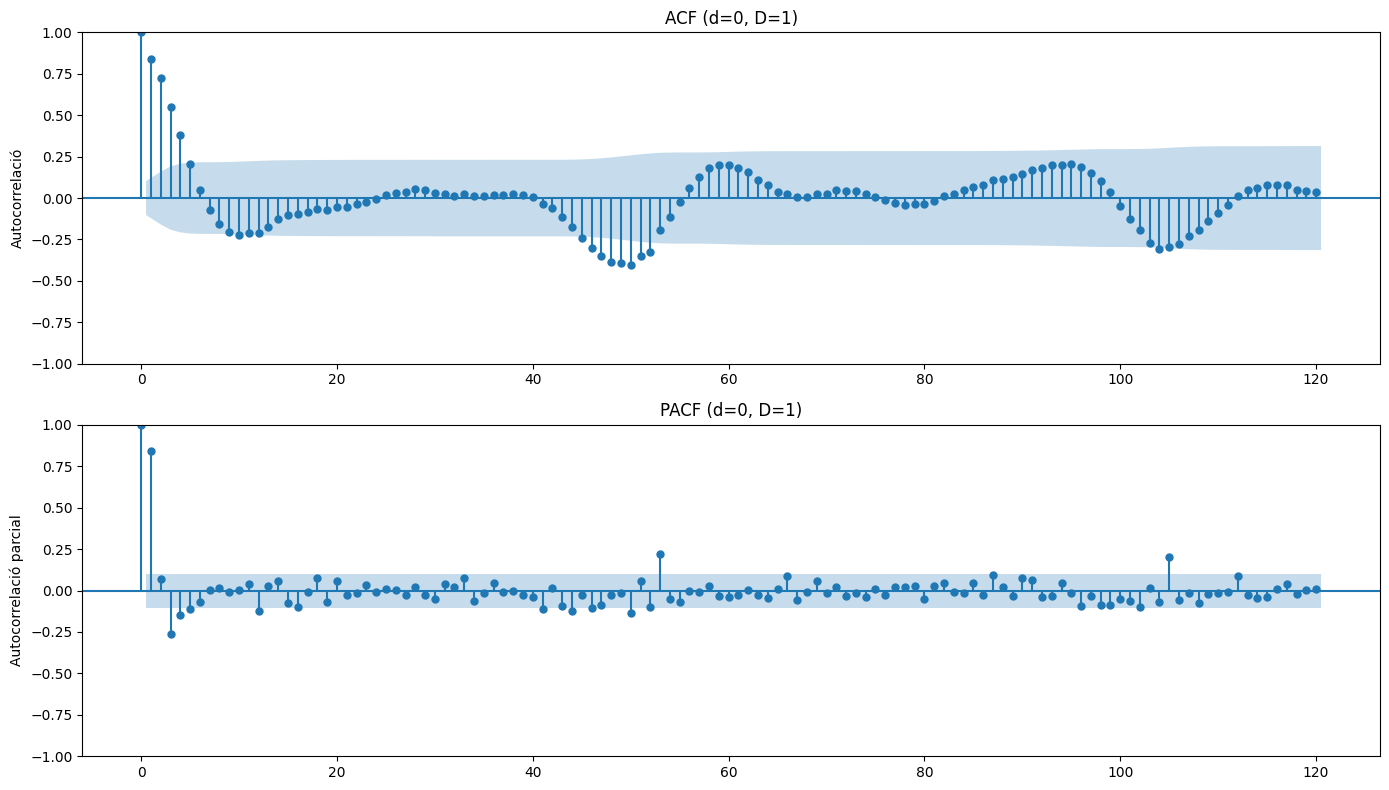

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_D1, lags=120, ax=axes[0])
axes[0].set_title("ACF (d=0, D=1)")
axes[0].set_ylabel("Autocorrelació")

plot_pacf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("PACF (d=0, D=1)")
axes[1].set_ylabel("Autocorrelació parcial")

plt.tight_layout()
plt.show()

## Anàlisi de l’ACF i la PACF

S’han examinat l’ACF i la PACF després d’aplicar l’esquema de diferenciació seleccionat (d = 0, D = 1) a la sèrie transformada logarítmicament.

L’ACF encara mostra una persistència rellevant a curt termini en els primers retards, juntament amb un patró estacional restant de magnitud molt menor que en la sèrie original. Això suggereix que encara és necessària una certa estructura ARMA no estacional després de la diferenciació estacional.

La PACF presenta un pic fort en el retard 1 i després disminueix ràpidament, fet que dona suport a considerar termes autoregressius d’ordre baix, especialment p = 1, i possiblement p = 2. Com que l’ACF tampoc no es talla bruscament, també es van considerar termes MA d’ordre baix.

En conjunt, l’estructura d’autocorrelació després de la diferenciació sembla compatible amb components ARMA no estacionals d’ordre baix, juntament amb un terme MA estacional d’ordre 1.

## Selecció del model

S'han explorat diversos models SARIMA a partir dels diagnòstics de l’ACF/PACF i de l’estructura estacional de la sèrie.

A la pràctica, durant la fase exploratòria es van considerar més especificacions, però el notebook presenta un conjunt reduït de models candidats amb les combinacions més raonables i interpretables. L’atenció s'ha centrat en:

- termes no estacionals d’ordre baix (p,q),
- diferenciació estacional (D = 1),
- i estructures estacionals amb Q = 1, comparant opcionalment P = 0 i P = 1.

Els models candidats s'han ajustat sobre el període d’entrenament i s'han comparat principalment mitjançant l’AIC, tenint també en compte la parsimònia del model i la significació dels coeficients.

In [14]:
models = [
    ((1,0,1), (1,1,1,52)),
    ((1,0,1), (0,1,1,52)),
    ((1,0,0), (1,1,1,52)),
    ((1,0,0), (0,1,1,52)),
    ((2,0,1), (1,1,1,52)),
    ((2,0,1), (0,1,1,52)),
    ((2,0,0), (1,1,1,52)),
    ((2,0,0), (0,1,1,52)),
    ((1,0,2), (1,1,1,52)),
    ((1,0,2), (0,1,1,52)),
    ((2,0,2), (1,1,1,52)),
    ((2,0,2), (0,1,1,52)),
    
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA {order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA {order}{seasonal_order}")

print("\n Millor model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA (1, 0, 1)(1, 1, 1, 52)
AIC: 73.16741665356994
----------------------------------------
Model SARIMA (1, 0, 1)(0, 1, 1, 52)
AIC: 64.84290219203625
----------------------------------------
Model SARIMA (1, 0, 0)(1, 1, 1, 52)
AIC: 70.88914104811015
----------------------------------------
Model SARIMA (1, 0, 0)(0, 1, 1, 52)
AIC: 62.23343235712323
----------------------------------------
Model SARIMA (2, 0, 1)(1, 1, 1, 52)
AIC: 75.04671399831004
----------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model SARIMA (2, 0, 1)(0, 1, 1, 52)
AIC: 65.65153925887165
----------------------------------------
Model SARIMA (2, 0, 0)(1, 1, 1, 52)
AIC: 73.09054540280545
----------------------------------------
Model SARIMA (2, 0, 0)(0, 1, 1, 52)
AIC: 64.38164100513634
----------------------------------------
Model SARIMA (1, 0, 2)(1, 1, 1, 52)
AIC: 64.14513249980934
----------------------------------------
Model SARIMA (1, 0, 2)(0, 1, 1, 52)
AIC: 52.147859819184816
----------------------------------------
Model SARIMA (2, 0, 2)(1, 1, 1, 52)
AIC: 49.36406985984296
----------------------------------------
Model SARIMA (2, 0, 2)(0, 1, 1, 52)
AIC: 41.18431197375384
----------------------------------------

 Millor model:
((2, 0, 2), (0, 1, 1, 52))
AIC: 41.18431197375384


In [15]:
model1 = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 52)   Log Likelihood                 -14.592
Date:                              Sat, 25 Apr 2026   AIC                             41.184
Time:                                      18:15:25   BIC                             63.623
Sample:                                  01-02-2012   HQIC                            50.153
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6713      0.089     18.745      0.000       1.497       1.846
ar.L2         -0.77

In [16]:
model2 = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(1,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2 = model2.fit()
print(result2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 52)   Log Likelihood                 -17.682
Date:                              Sat, 25 Apr 2026   AIC                             49.364
Time:                                      18:15:34   BIC                             75.543
Sample:                                  01-02-2012   HQIC                            59.828
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6960      0.086     19.652      0.000       1.527       1.865
ar.L2         -0.78

In [17]:
model3 = SARIMAX(train_log,
                order=(1,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result3 = model3.fit()
print(result3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 52)   Log Likelihood                 -21.074
Date:                              Sat, 25 Apr 2026   AIC                             52.148
Time:                                      18:15:39   BIC                             70.847
Sample:                                  01-02-2012   HQIC                            59.622
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7824      0.051     15.385      0.000       0.683       0.882
ma.L1          0.05

In [18]:
model4 = SARIMAX(train_log,
                order=(1,0,0),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result4 = model4.fit()
print(result4.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 52)   Log Likelihood                 -28.117
Date:                              Sat, 25 Apr 2026   AIC                             62.233
Time:                                      18:15:43   BIC                             73.472
Sample:                                  01-02-2012   HQIC                            66.725
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8447      0.029     29.188      0.000       0.788       0.901
ma.S.L52      -1.01

## Selecció del model per a la validació residual

S’han conservat quatre models per a una comparació més detallada:

- SARIMA(2,0,2)(0,1,1,52)
- SARIMA(2,0,2)(1,1,1,52)
- SARIMA(1,0,2)(0,1,1,52)
- SARIMA(1,0,0)(0,1,1,52)

Els tres primers s’han seleccionat perquè assoleixen els valors d’AIC més baixos entre els models ajustats. L’últim s’ha inclòs tot i tenir un AIC més elevat, a causa de la seva estructura molt més simple, fet que el converteix en una referència parsimoniosa útil.

Per tant, l’elecció final no es basa només en l’ajust dins de la mostra, sinó també en els diagnòstics residuals, el rendiment predictiu i la parsimònia.

Per dur a terme una avaluació residual més rigorosa, l’anàlisi diagnòstica s’ha fet excloent el període inicial de burn-in de cada model ajustat. Aquest pas es justifica per la representació en espai d’estats utilitzada en l’estimació SARIMA, on els primers residus poden estar afectats per la inicialització del filtre i, per tant, poden no ser completament representatius del comportament residual estable del model. Per aquest motiu, els diagnòstics residuals es basen només en els residus posteriors al burn-in.

Burn-in utilitzat: 107


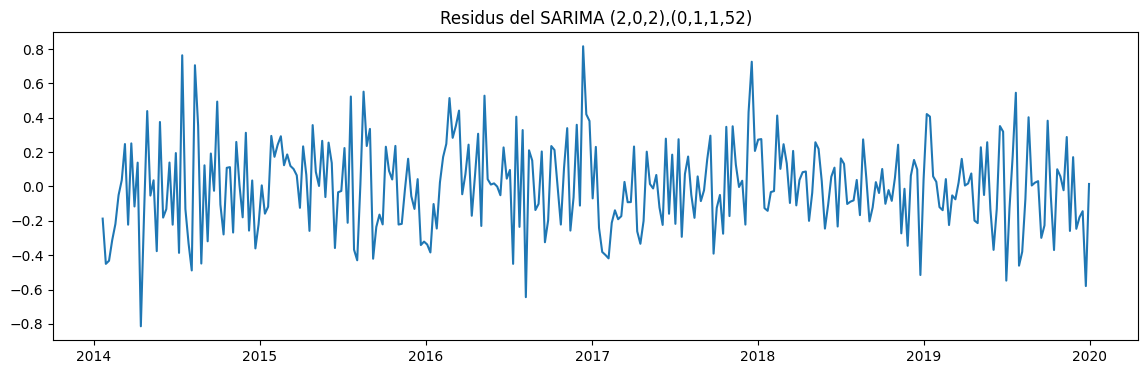

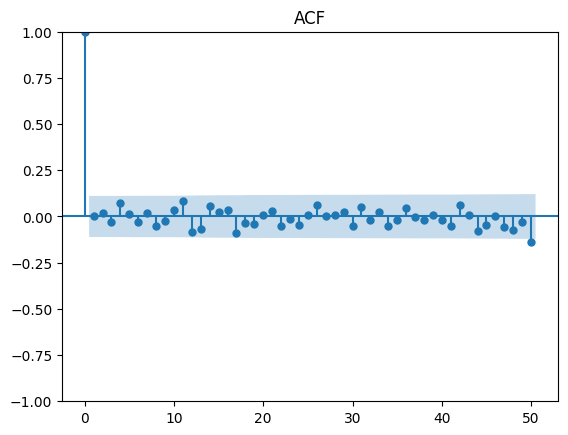


 Ljung Box
      lb_stat  lb_pvalue
10   3.938588   0.950075
20  15.360695   0.755410
30  19.630341   0.925812

Mitjana dels residus: 0.001068173749429341
Desviació estàndard dels residus: 0.2559004776798135
Mitjana relativa (|mitjana| / desviació estàndard): 0.004174176457637785


In [19]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual1 = residuals.iloc[burn:].copy()


plt.figure(figsize=(14,4))
plt.plot(residual1)
plt.title("Residus del SARIMA (2,0,2),(0,1,1,52)")
plt.show()

plot_acf(residual1, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual1, lags=[10, 20, 30], return_df=True))

mean_resid = residual1.mean()
std_resid = residual1.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

Burn-in utilitzat: 107


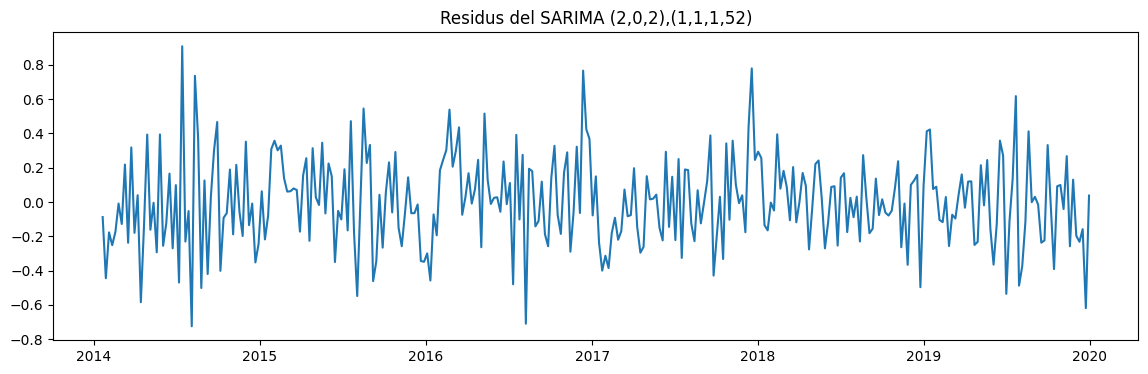

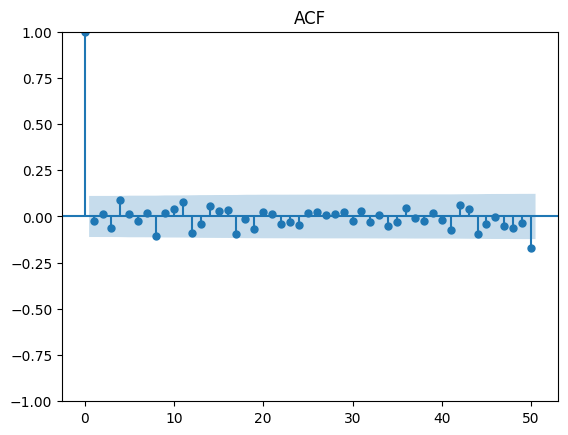


 Ljung Box
      lb_stat  lb_pvalue
10   8.666629   0.564007
20  20.496646   0.427272
30  22.961476   0.816840

Mitjana dels residus: 0.001530715232005652
Desviació estàndard dels residus: 0.25970725394562105
Mitjana relativa (|mitjana| / desviació estàndard): 0.005894002607744494


In [20]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual2)
plt.title("Residus del SARIMA (2,0,2),(1,1,1,52)")
plt.show()

plot_acf(residual2, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual2, lags=[10, 20, 30], return_df=True))

mean_resid = residual2.mean()
std_resid = residual2.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

Burn-in utilitzat: 107


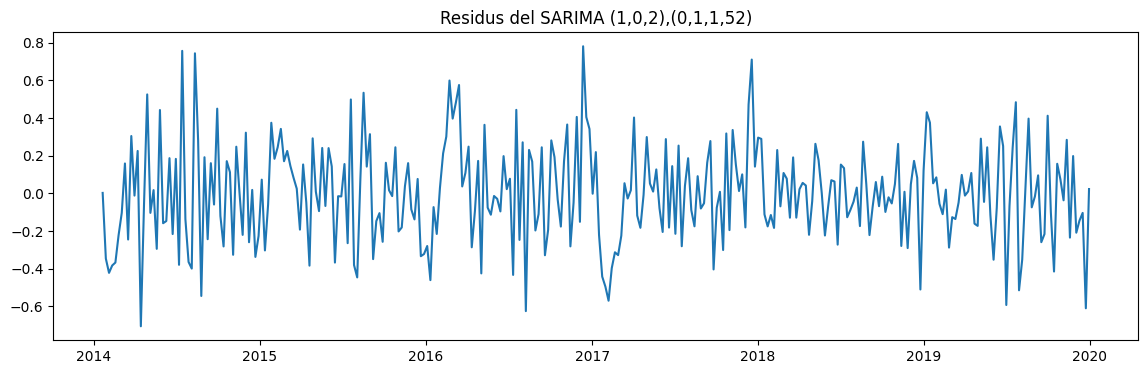

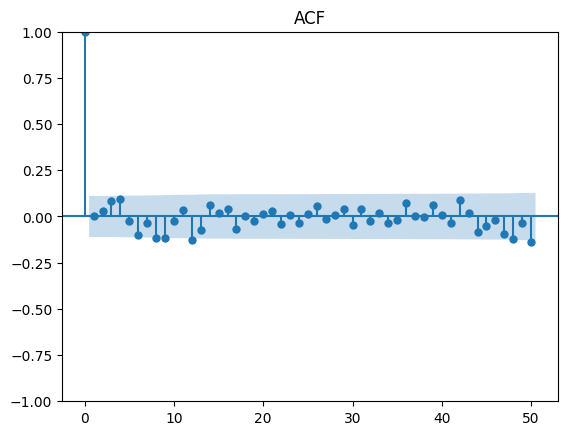


 Ljung Box
      lb_stat  lb_pvalue
10  18.191685   0.051815
20  29.187050   0.084141
30  33.146558   0.316217

Mitjana dels residus: -0.0018264516072886644
Desviació estàndard dels residus: 0.26132933155667204
Mitjana relativa (|mitjana| / desviació estàndard): 0.006989080010303317


In [21]:
residuals= result3.resid.dropna()
burn = max(result3.loglikelihood_burn, result3.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual3 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual3)
plt.title("Residus del SARIMA (1,0,2),(0,1,1,52)")
plt.show()

plot_acf(residual3, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual3, lags=[10, 20, 30], return_df=True))

mean_resid = residual3.mean()
std_resid = residual3.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

Burn-in utilitzat: 105


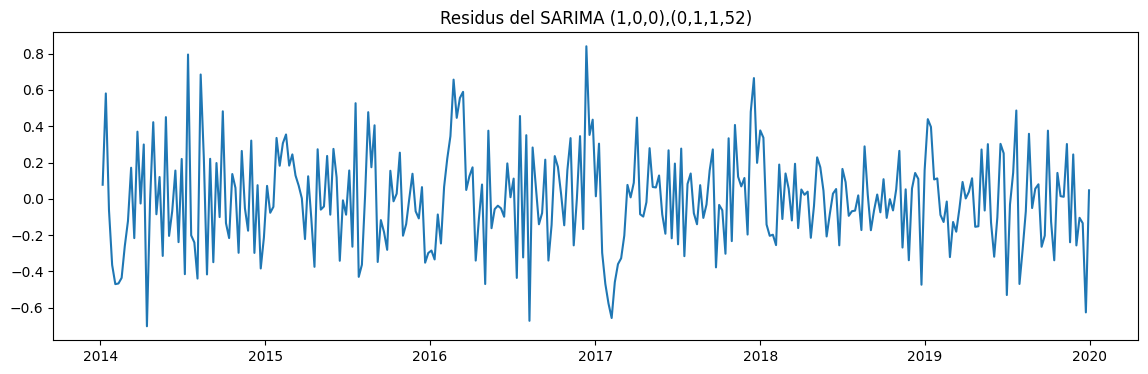

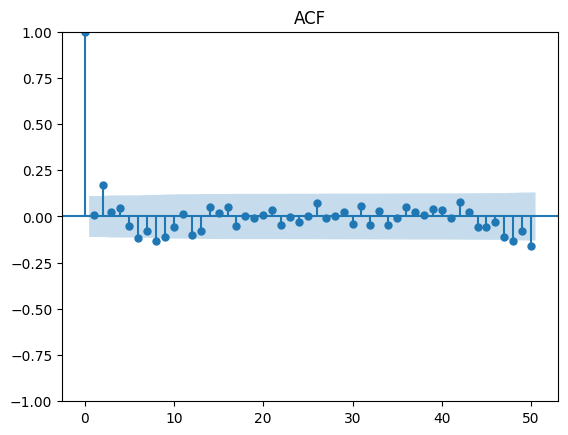


 Ljung Box
      lb_stat  lb_pvalue
10  28.256449   0.001642
20  36.339450   0.014027
30  40.383408   0.097649

Mitjana dels residus: 0.000513038394393047
Desviació estàndard dels residus: 0.26732723962048105
Mitjana relativa (|mitjana| / desviació estàndard): 0.0019191399840936413


In [22]:
residuals= result4.resid.dropna()
burn = max(result4.loglikelihood_burn, result4.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual4 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual4)
plt.title("Residus del SARIMA (1,0,0),(0,1,1,52)")
plt.show()

plot_acf(residual4, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual4, lags=[10, 20, 30], return_df=True))

mean_resid = residual4.mean()
std_resid = residual4.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

## Resultats de la validació residual

S’han analitzat els residus dels quatre models candidats conservats amb l’objectiu d’avaluar-ne l’adequació.

Els models SARIMA(2,0,2)(0,1,1) i SARIMA(2,0,2)(1,1,1) mostren el comportament residual més satisfactori, amb una autocorrelació residual baixa i resultats del test de Ljung–Box compatibles amb una estructura de soroll blanc. 
En canvi, el model SARIMA(1,0,2)(0,1,1) presenta diagnòstics residuals més febles en els primers retards, mentre que el model SARIMA(1,0,0)(0,1,1) mostra evidència més clara de dependència residual restant i, per tant, es considera menys adequat.

In [23]:
# Model 1
pred1 = result1.get_forecast(steps=len(test_log))
pred1_mean = pred1.predicted_mean

mae1 = mean_absolute_error(test_log, pred1_mean)
rmse1 = root_mean_squared_error(test_log, pred1_mean)

# Model 2
pred2 = result2.get_forecast(steps=len(test_log))
pred2_mean = pred2.predicted_mean

mae2 = mean_absolute_error(test_log, pred2_mean)
rmse2 = root_mean_squared_error(test_log, pred2_mean)

# Model 3
pred3 = result3.get_forecast(steps=len(test_log))
pred3_mean = pred3.predicted_mean

mae3 = mean_absolute_error(test_log, pred3_mean)
rmse3 = root_mean_squared_error(test_log, pred3_mean)


print("Model (2,0,2)(0,1,1) → MAE:", mae1, "RMSE:", rmse1)
print("Model (2,0,2)(1,1,1) → MAE:", mae2, "RMSE:", rmse2)
print("Model (1,0,2)(0,1,1) → MAE:", mae3, "RMSE:", rmse3)

Model (2,0,2)(0,1,1) → MAE: 0.8654429330605927 RMSE: 1.1091938964308345
Model (2,0,2)(1,1,1) → MAE: 0.8617657448475547 RMSE: 1.1043618072729295
Model (1,0,2)(0,1,1) → MAE: 0.8664664129150937 RMSE: 1.1073200291276597


## Selecció final del model

Tot i que el model SARIMA(2,0,2)(1,1,1) assoleix valors lleugerament inferiors de MAE i RMSE en el petit exercici de validació predictiva, la millora és només marginal. En canvi, el model SARIMA(2,0,2)(0,1,1) obté un AIC clarament més baix, tots els coeficients estimats són estadísticament significatius i els seus diagnòstics residuals resulten globalment més satisfactoris.

Per tant, el model SARIMA(2,0,2)(0,1,1) se selecciona com a especificació final per a aquesta sèrie, ja que proporciona el millor equilibri global entre qualitat d’ajust, adequació residual i interpretabilitat del model.

## Predicció

Un cop s’ha validat el model, es generen prediccions utilitzant l’horitzó del conjunt de prova. L’objectiu és avaluar fins a quin punt el model capta:

- la tendència global
- el patró estacional
- la variabilitat de la sèrie

Les prediccions s’acompanyen d’intervals de predicció, que reflecteixen la incertesa del model.

In [24]:
model = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log) 

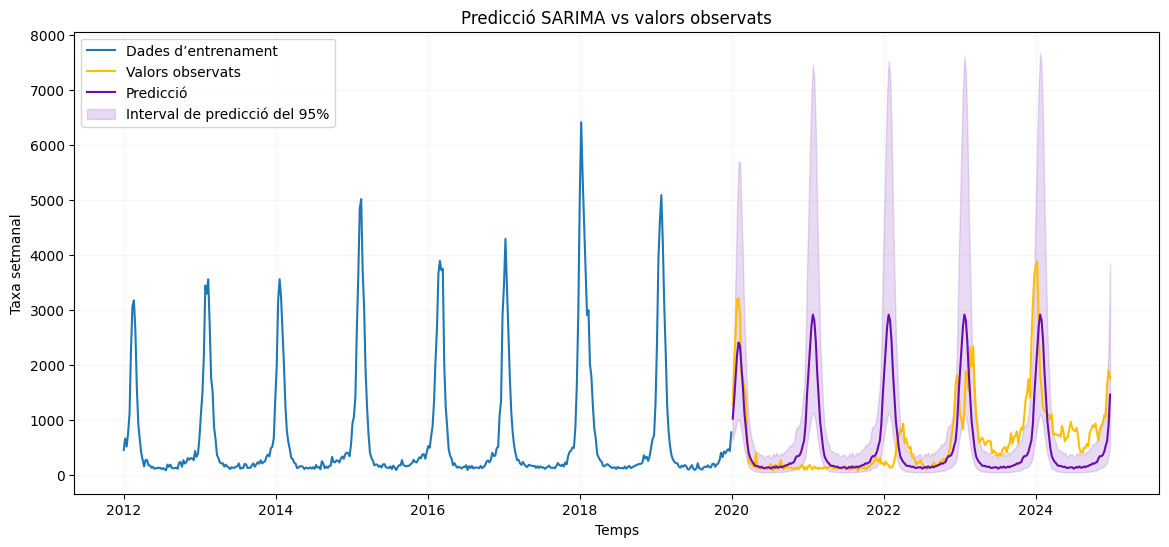

In [25]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Dades d’entrenament', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.legend()
plt.title("Predicció SARIMA vs valors observats")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)
plt.show()

In [26]:
mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)

covTotal = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

print("TOTAL")
print("MAE:", mae_total)
print("RMSE:", rmse_total)
print("Cobertura:", covTotal)

TOTAL
MAE: 503.5526703034023
RMSE: 780.2890089976131
Cobertura: 0.5846153846153846


## Avaluació de la predicció

Per avaluar quantitativament el rendiment predictiu, es calculen mètriques d’error com:

- Error absolut mitjà (MAE)
- Arrel de l’error quadràtic mitjà (RMSE)

Aquestes mètriques mesuren la diferència entre els valors observats i els valors predits, i permeten avaluar la precisió del model.
La cobertura empírica dels intervals de predicció del 95% és aproximadament de 0'58, per sota del nivell nominal, fet que suggereix que la incertesa de predicció queda infraestimada.

Per investigar més a fons aquesta qüestió, el període de prova es divideix en dos subperíodes:

- Període COVID
- Període post-COVID

Això permet analitzar si el model es comporta de manera diferent davant canvis estructurals en les dades.

In [27]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

 
mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)

cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

print("\nCOVID (2020-2021)")
print("MAE:", mae_covid)
print("RMSE:", rmse_covid)
print("Cobertura:", cov_covid)


mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)

cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

print("\nPOST-COVID (2022-2024)")
print("MAE:", mae_post)
print("RMSE:", rmse_post)
print("Cobertura:", cov_post)


COVID (2020-2021)
MAE: 337.324526572098
RMSE: 691.9585333144156
Cobertura: 0.8076923076923077

POST-COVID (2022-2024)
MAE: 614.3714327909386
RMSE: 833.9946970573037
Cobertura: 0.4358974358974359


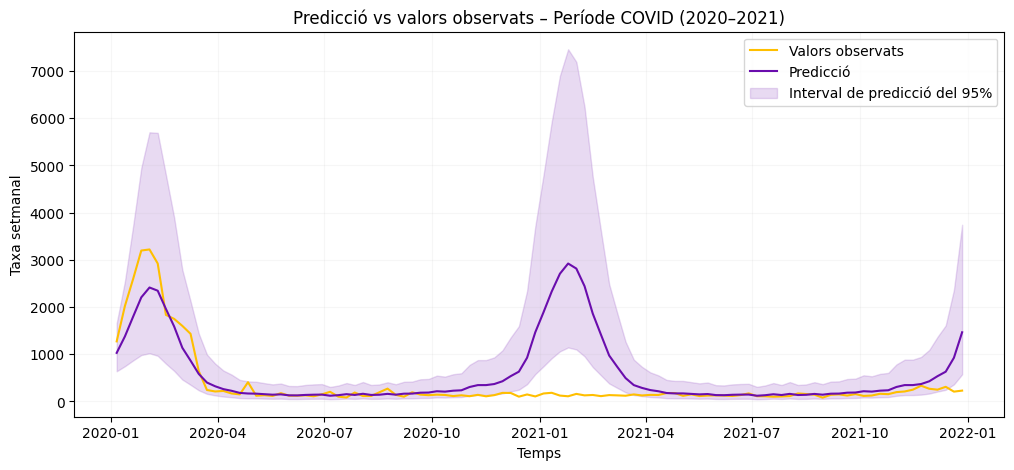

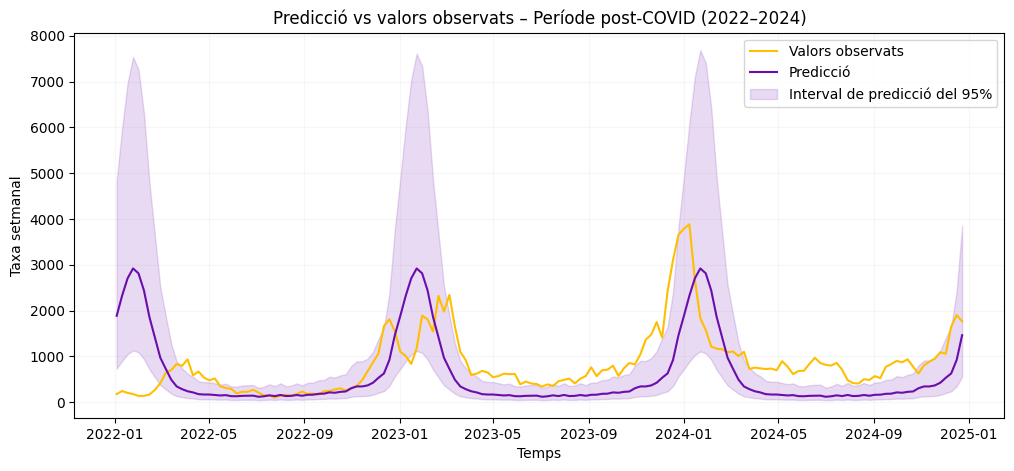

In [28]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Predicció vs valors observats – Període COVID (2020–2021)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Predicció vs valors observats – Període post-COVID (2022–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

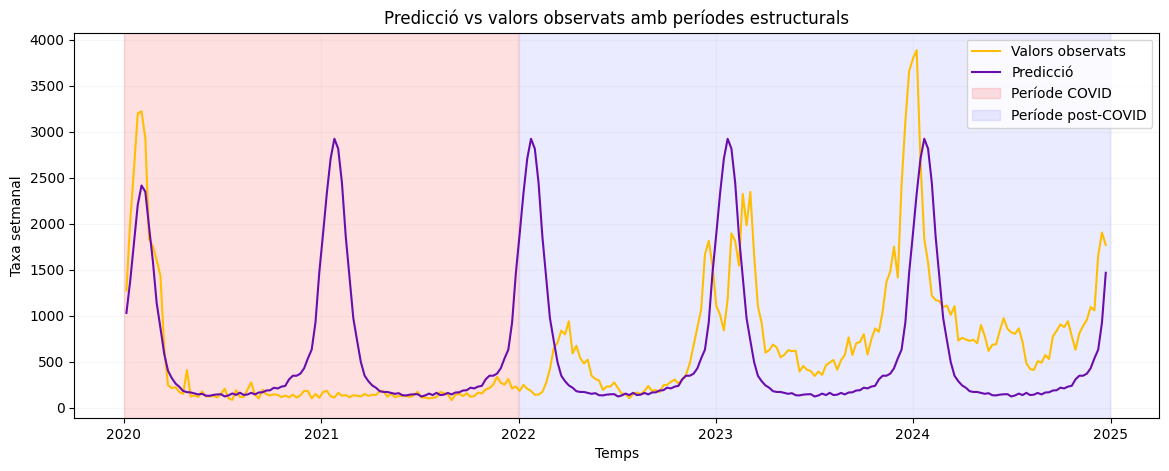

In [29]:
plt.figure(figsize=(14,5))

plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.axvspan(pd.to_datetime("2020-01-01"),
            pd.to_datetime("2021-12-31"),
            color='red', alpha=0.12, label='Període COVID')

plt.axvspan(pd.to_datetime("2022-01-01"),
            pd.to_datetime("2024-12-31"),
            color='blue', alpha=0.08, label='Període post-COVID')

plt.legend()
plt.title("Predicció vs valors observats amb períodes estructurals")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)

plt.show()

## Anàlisi visual

El model es comporta de manera diferent durant el període COVID (2020–2021) i durant el període post-COVID (2022–2024).

Durant la COVID, el model infraestima el gran pic inicial i no pot reproduir la disrupció causada per la pandèmia. Tot i així, un cop passat el primer xoc, la sèrie observada es manté en nivells relativament baixos, de manera que els errors globals de predicció són moderats i la cobertura es manté raonablement elevada.

Una interpretació plausible és que el patró habitual de la grip va quedar temporalment distorsionat per la pandèmia, a causa dels canvis en la circulació dels virus respiratoris, les mesures de salut pública i el possible solapament entre casos similars a la grip i diagnòstics relacionats amb la COVID.

En el període post-COVID, el model presenta un rendiment pitjor. Encara capta el patró estacional general, però no aconsegueix reproduir el nou nivell basal ni la major variabilitat observada entre els pics epidèmics. Això comporta errors de predicció més elevats i una cobertura molt més baixa.

Per tant, els resultats suggereixen que la principal dificultat no és només el xoc de la COVID en si mateix, sinó també el canvi estructural en la dinàmica de la grip després de la pandèmia.